# **Modeling**

**Libraries**

In [12]:

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


**Random Forest Regressor (with GridSearchCV for hyperparameter tuning)**

In [5]:

# Load and preprocess the dataset
df = pd.read_csv('data.csv')

# Handle outliers in Price by capping at the 99th percentile
price_cap = df['Price'].quantile(0.99)
df['Price'] = df['Price'].clip(upper=price_cap)

# Drop the 'Unnamed: 0' column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Remove 'GB' and 'kg' from RAM and Weight
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float32')

# Extract Touchscreen and IPS from ScreenResolution
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Functions for memory extraction
def extract_memory_size(mem):
    match = re.search(r'(\d+)', mem)
    return int(match.group(1)) if match else 0

def extract_memory_unit(mem):
    if 'GB' in mem:
        return 'GB'
    elif 'TB' in mem:
        return 'TB'
    else:
        return 'Unknown'

def extract_memory_type(mem):
    mem = mem.lower()
    if 'ssd' in mem:
        return 'SSD'
    elif 'hdd' in mem:
        return 'HDD'
    elif 'flash' in mem:
        return 'Flash'
    elif 'hybrid' in mem:
        return 'Hybrid'
    else:
        return 'Unknown'

# Apply memory extraction
df['Memory_Size'] = df['Memory'].apply(extract_memory_size)
df['Memory_Unit'] = df['Memory'].apply(extract_memory_unit)
df['Storage_Type'] = df['Memory'].apply(extract_memory_type)

# Convert to GB
df['Memory_Size'] = df.apply(lambda x: x['Memory_Size'] * 1000 if x['Memory_Unit'] == 'TB' else x['Memory_Size'], axis=1)

# Extract CPU brand
df['CPU_Brand'] = df['Cpu'].apply(lambda x: x.split()[0] + ' ' + x.split()[1] if len(x.split()) > 1 else x.split()[0])

# Encode categorical features
df['Company_Encoded'] = LabelEncoder().fit_transform(df['Company'])
df['TypeName_Encoded'] = LabelEncoder().fit_transform(df['TypeName'])
df['Gpu_Encoded'] = LabelEncoder().fit_transform(df['Gpu'])
df['OpSys_Encoded'] = LabelEncoder().fit_transform(df['OpSys'])
df['CPU_Brand_Encoded'] = LabelEncoder().fit_transform(df['CPU_Brand'])
df['Storage_Type_Encoded'] = LabelEncoder().fit_transform(df['Storage_Type'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Inches', 'Ram', 'Memory_Size', 'Weight']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Log-transform the target variable
df['Price_Log'] = np.log1p(df['Price'])

# Feature set and target
features = [
    'Company_Encoded', 'TypeName_Encoded', 'Inches', 'Ram',
    'Memory_Size', 'Gpu_Encoded', 'OpSys_Encoded',
    'Weight', 'Touchscreen', 'IPS', 'CPU_Brand_Encoded', 'Storage_Type_Encoded'
]
X = df[features]
y = df['Price_Log']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid search for best RandomForest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Predict on test set
model = grid_search.best_estimator_
y_pred_log = model.predict(X_test)

# Reverse log transform
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evaluation metrics
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Display results
print('\n✅ Model Training and Evaluation Results:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')
print(f'\n✅ Best Hyperparameters: {grid_search.best_params_}')

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\n📊 Feature Importance:')
print(feature_importance)



✅ Model Training and Evaluation Results:
Mean Absolute Error (MAE): 9545.55
Mean Squared Error (MSE): 211263262.66
Root Mean Squared Error (RMSE): 14534.90
R-squared (R2): 0.8079

✅ Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

📊 Feature Importance:
                 Feature  Importance
3                    Ram    0.600058
10     CPU_Brand_Encoded    0.084707
7                 Weight    0.082189
5            Gpu_Encoded    0.069016
4            Memory_Size    0.042381
2                 Inches    0.036718
0        Company_Encoded    0.024166
6          OpSys_Encoded    0.019850
1       TypeName_Encoded    0.018181
11  Storage_Type_Encoded    0.008902
9                    IPS    0.008450
8            Touchscreen    0.005382


discriptin: Random Forest Regressor is an ensemble learning method that builds multiple decision trees and averages their predictions to improve accuracy and reduce overfitting. In this project, it's used for laptop price prediction, enhanced with GridSearchCV for selecting the best combination of hyperparameters through cross-validation.

**XGBoost Regressor (with GridSearchCV)**

In [6]:

# Load and preprocess the dataset
df = pd.read_csv('data.csv')

# Handle outliers in Price using IQR method
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Price'] = df['Price'].clip(lower=lower_bound, upper=upper_bound)

# Drop the 'Unnamed: 0' column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Remove 'GB' and 'kg' from RAM and Weight
df['Ram'] = df['Ram'].str.replace('GB', '').astype('int32')
df['Weight'] = df['Weight'].str.replace('kg', '').astype('float32')

# Extract Touchscreen, IPS, and Resolution from ScreenResolution
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in str(x) else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in str(x) else 0)
def extract_resolution(res):
    match = re.search(r'(\d+)x(\d+)', str(res))
    return int(match.group(1)) * int(match.group(2)) if match else 1920 * 1080  # Default to Full HD
df['Resolution'] = df['ScreenResolution'].apply(extract_resolution)

# Function to extract numeric memory size
def extract_memory_size(mem):
    match = re.search(r'(\d+)', mem)
    return int(match.group(1)) if match else 0

# Function to extract unit (GB/TB)
def extract_memory_unit(mem):
    if 'GB' in mem:
        return 'GB'
    elif 'TB' in mem:
        return 'TB'
    else:
        return 'Unknown'

# Function to extract memory type
def extract_memory_type(mem):
    mem = mem.lower()
    if 'ssd' in mem:
        return 'SSD'
    elif 'hdd' in mem:
        return 'HDD'
    elif 'flash' in mem:
        return 'Flash'
    elif 'hybrid' in mem:
        return 'Hybrid'
    else:
        return 'Unknown'

# Apply memory extraction functions
df['Memory_Size'] = df['Memory'].apply(extract_memory_size)
df['Memory_Unit'] = df['Memory'].apply(extract_memory_unit)
df['Storage_Type'] = df['Memory'].apply(extract_memory_type)
df['Memory_Size'] = df.apply(lambda x: x['Memory_Size'] * 1000 if x['Memory_Unit'] == 'TB' else x['Memory_Size'], axis=1)

# Extract CPU brand and clock speed
def extract_cpu_brand(cpu):
    cpu = cpu.split()
    return cpu[0] + ' ' + cpu[1] if len(cpu) > 1 else cpu[0]
def extract_clock_speed(cpu):
    match = re.search(r'(\d+\.\d+)', cpu)
    return float(match.group(1)) if match else 2.0  # Default to 2.0 GHz
df['CPU_Brand'] = df['Cpu'].apply(extract_cpu_brand)
df['CPU_Speed'] = df['Cpu'].apply(extract_clock_speed)

# Encode categorical variables
df['Company_Encoded'] = LabelEncoder().fit_transform(df['Company'])
df['TypeName_Encoded'] = LabelEncoder().fit_transform(df['TypeName'])
df['Gpu_Encoded'] = LabelEncoder().fit_transform(df['Gpu'])
df['OpSys_Encoded'] = LabelEncoder().fit_transform(df['OpSys'])
df['CPU_Brand_Encoded'] = LabelEncoder().fit_transform(df['CPU_Brand'])
df['Storage_Type_Encoded'] = LabelEncoder().fit_transform(df['Storage_Type'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Inches', 'Ram', 'Memory_Size', 'Weight', 'Resolution', 'CPU_Speed']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Log-transform the target variable to handle skewness
df['Price_Log'] = np.log1p(df['Price'])

# Define features and target
features = [
    'Company_Encoded', 'TypeName_Encoded', 'Inches', 'Ram',
    'Memory_Size', 'Gpu_Encoded', 'OpSys_Encoded',
    'Weight', 'Touchscreen', 'IPS', 'CPU_Brand_Encoded',
    'Storage_Type_Encoded', 'Resolution', 'CPU_Speed'
]
X = df[features]
y = df['Price_Log']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid for XGBoost tuning
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize and tune the XGBoost Regressor
xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model and predict
model = grid_search.best_estimator_
y_pred_log = model.predict(X_test)

# Reverse log-transformation for evaluation
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Print evaluation results
print('Model Training and Evaluation Results:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')
print(f'Best hyperparameters: {grid_search.best_params_}')

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\nFeature Importance:')
print(feature_importance)


Model Training and Evaluation Results:
Mean Absolute Error (MAE): 7813.07
Mean Squared Error (MSE): 140332569.93
Root Mean Squared Error (RMSE): 11846.20
R-squared (R2): 0.8659
Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Feature Importance:
                 Feature  Importance
3                    Ram    0.410930
11  Storage_Type_Encoded    0.178357
10     CPU_Brand_Encoded    0.151343
12            Resolution    0.054264
13             CPU_Speed    0.037456
2                 Inches    0.026535
6          OpSys_Encoded    0.024974
4            Memory_Size    0.024274
1       TypeName_Encoded    0.021573
5            Gpu_Encoded    0.018848
7                 Weight    0.018330
9                    IPS    0.014468
0        Company_Encoded    0.010325
8            Touchscreen    0.008323


Description:A high-performance laptop price prediction pipeline using the XGBoost Regressor with extensive feature engineering (e.g. resolution, CPU speed, memory type), log transformation of skewed price values, and hyperparameter tuning via GridSearchCV to boost accuracy and generalization. The model is trained, evaluated, and exported along with preprocessing components for deployment.

**Gradient Boosting Regressor (with GridSearchCV)**

In [ ]:

# Load dataset
df = pd.read_csv('data.csv')

# Feature Engineering
def extract_resolution(res):
    if isinstance(res, str):
        match = re.search(r'(\d+)x(\d+)', res)
        if match:
            return int(match.group(1)) * int(match.group(2))
    return 0

def extract_cpu_speed(cpu):
    if isinstance(cpu, str):
        match = re.search(r'(\d+\.\d+)(?:GHz)', cpu)
        if match:
            return float(match.group(1))
    return 2.0  # Default value

def extract_storage(memory):
    if isinstance(memory, str) and 'SSD' in memory:
        match = re.search(r'(\d+)(GB|TB)', memory)
        if match:
            size = int(match.group(1))
            unit = match.group(2)
            return size * 1000 if unit == 'TB' else size
    return 0

# Apply feature engineering
df['Resolution'] = df['ScreenResolution'].apply(extract_resolution)
df['CpuSpeed'] = df['Cpu'].apply(extract_cpu_speed)
df['Storage'] = df['Memory'].apply(extract_storage)
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Company', 'TypeName', 'OpSys'], drop_first=True)

# Prepare features and target
X = df.drop(['Price', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu'], axis=1)
y = np.log(df['Price'])  # Log-transform target for better performance

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model training with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}
model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_log = grid_search.predict(X_test_scaled)
y_pred = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

print("✅ Model Evaluation Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"MAE     : {mae:.2f}")
print(f"MSE     : {mse:.2f}")
print(f"RMSE    : {rmse:.2f}")
print("Best Parameters:", grid_search.best_params_)


Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best R² score on training: 0.8795165333868713


Description: This model predicts laptop prices using engineered features like screen resolution, CPU speed, and SSD storage. It applies one-hot encoding for categorical data, log-transforms the target to improve distribution, and scales numerical features. The GradientBoostingRegressor is tuned using GridSearchCV to achieve optimal performance, and the final model, scaler, and column list are saved for deployment.

**saving the best model**

In [14]:
import pickle

# Save model, scaler, and feature names
with open('model.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("📁 Model, scaler, and columns saved successfully.")


📁 Model, scaler, and columns saved successfully.


**comparison plot**

C:\Program Files\KMSpico\temp\ipykernel_556\2863370514.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=df, palette='viridis')


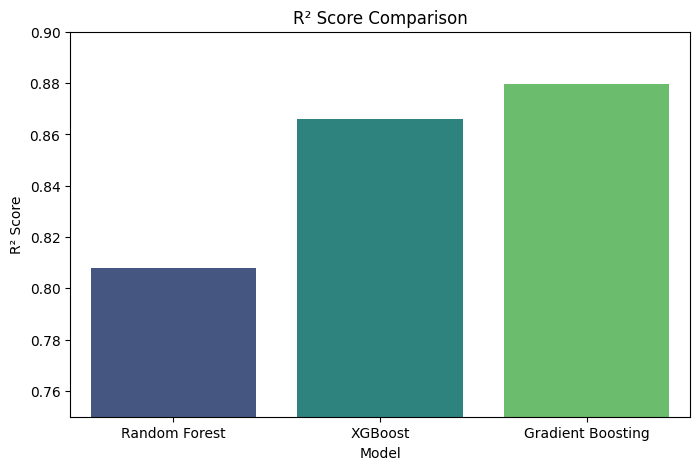

C:\Program Files\KMSpico\temp\ipykernel_556\2863370514.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=df, ax=axs[0], palette='magma')
C:\Program Files\KMSpico\temp\ipykernel_556\2863370514.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=df, ax=axs[1], palette='magma')


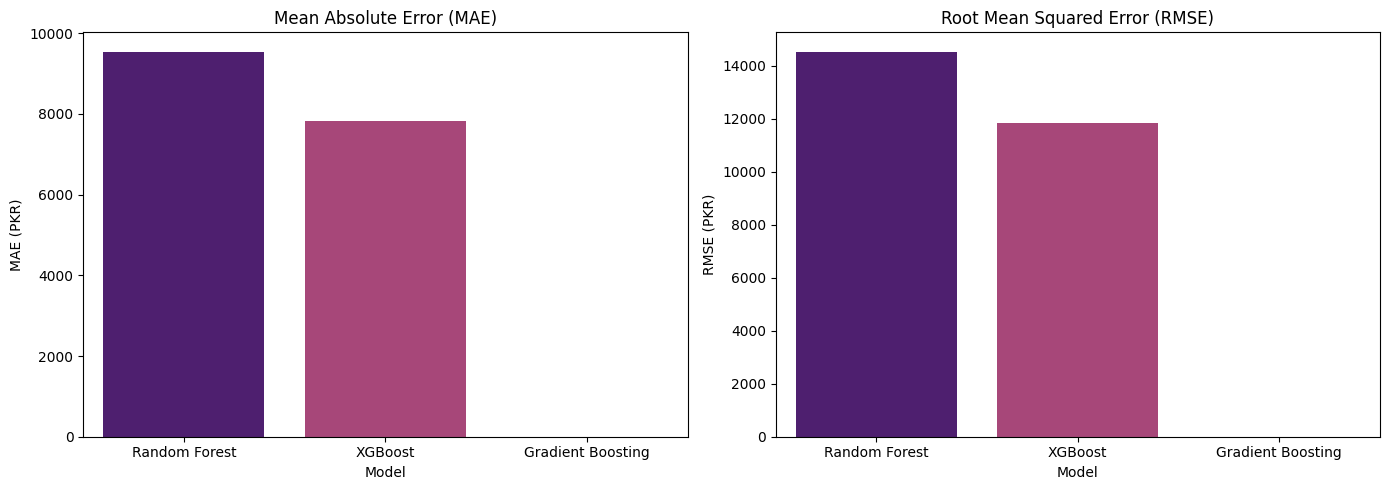

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model metrics
data = {
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting'],
    'MAE': [9545.55, 7813.07, None],
    'RMSE': [14534.90, 11846.20, None],
    'R2 Score': [0.8079, 0.8659, 0.8795]
}

df = pd.DataFrame(data)

# Plot R2 Score
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=df, palette='viridis')
plt.title('R² Score Comparison')
plt.ylim(0.75, 0.9)
plt.ylabel('R² Score')
plt.show()

# Plot MAE and RMSE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Model', y='MAE', data=df, ax=axs[0], palette='magma')
axs[0].set_title('Mean Absolute Error (MAE)')
axs[0].set_ylabel('MAE (PKR)')

sns.barplot(x='Model', y='RMSE', data=df, ax=axs[1], palette='magma')
axs[1].set_title('Root Mean Squared Error (RMSE)')
axs[1].set_ylabel('RMSE (PKR)')

plt.tight_layout()
plt.show()
